# TUBES DAI Fraud Detection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
sample = pd.read_csv("sample_submission.csv")


In [2]:
train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,M,UK,mobile,Android,clothing,17.70,...,0.793,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,F,IN,mobile,Android,restaurants,NaN,...,NaN,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,M,US,desktop,iOS,restaurants,5.20,...,0.281,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,F,US,mobile,Android,electronics,180.70,...,0.061,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,M,UK,mobile,Android,gas,35.45,...,0.592,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,M,IN,mobile,Android,electronics,7.67,...,0.888,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,F,UK,mobile,Android,restaurants,47.95,...,0.306,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,F,US,mobile,Android,services,44.29,...,0.735,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,M,IN,mobile,Windows,electronics,NaN,...,NaN,906,0,1,2,0.30,0.10,67.30,0,0


In [3]:
train.isna().sum() 

ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
is_fraud                     0
dtype: int64

# 1. Data Description

menjelaskan identitas data yang mewakili analaisis pola, pengenalan anomali, dsb.  Terdiri atas:
* memahami struktur data
* memeriksa nilai-nilai tingkasan statistik

## 1.1 Memahami struktur data
* Informasi Atributes
* Tipe Data per Atributes
* Jumlah baris dan kolom

In [4]:
# Informasi atributes 
# Notes: dibuat dalam tabel (dataframes) untuk mempermudah visualisasi

info_list = []


for column, dtype in train.dtypes.items():
    min_range = "-"
    max_range = "-"
    if dtype.name == 'int64':
        jenis_data = "Integer"
        min_range = train[column].min()
        max_range = train[column].max()
    elif dtype.name == 'float64':
        jenis_data = "Real"
        min_range = train[column].min()
        max_range = train[column].max()
    else:
        jenis_data = "Kategorikal"

    info_dict = {
        "Nama Atributtes" : column,
        "Jenis_Data": jenis_data,
        "Missing Values": train[column].isna().sum(),
        "Min Range": min_range,
        "Max Range": max_range
    }
    info_list.append(info_dict)

df_info = pd.DataFrame(info_list)
df_info

,Nama Atributtes,Jenis_Data,Missing Values,Min Range,Max Range
0,ID,Integer,0,0,99999
1,transaction_id,Kategorikal,0,-,-
2,user_id,Integer,0,1,29999
3,age,Integer,0,18,79
4,gender,Kategorikal,0,-,-
5,country,Kategorikal,0,-,-
6,device_type,Kategorikal,0,-,-
7,device_os,Kategorikal,0,-,-
8,merchant_category,Kategorikal,0,-,-
9,transaction_amount,Real,2419,0.01,20601.13335


In [5]:
# Untuk mengetahui jumlah baris dan kolom

print("="*100)
print(f"Jumlah Baris:    {train.shape[0]}")
print(f"Jumlah Kolom:    {train.shape[1]}")
print("="*100)

Jumlah Baris:    100000
Jumlah Kolom:    31


## 2. Mengetahui Nilai-Nilai Ringkasan Statistik

In [6]:
print(train.describe())

                  ID        user_id            age  transaction_amount  \
count  100000.000000  100000.000000  100000.000000        97581.000000   
mean    49999.500000   15040.173180      48.484150          126.855288   
std     28867.657797    8655.074007      17.892168          376.035544   
min         0.000000       1.000000      18.000000            0.010000   
25%     24999.750000    7549.000000      33.000000           26.910000   
50%     49999.500000   15093.000000      48.000000           64.460000   
75%     74999.250000   22541.000000      64.000000          131.060000   
max     99999.000000   29999.000000      79.000000        20601.133350   

         time_of_day    day_of_week  transaction_duration  \
count  100000.000000  100000.000000         100000.000000   
mean       12.770160       2.780700              3.999587   
std         5.748626       2.064754              4.012831   
min         0.000000       0.000000              0.000000   
25%         8.000000       1

# Preprocessing

In [7]:
# Lihat hanya kolom yang ada NaN nya
print("="*100)
print("Kolom yang mengandung NaN:")
nan_columns = train.columns[train.isna().any()].tolist()
print(train[nan_columns].isna().sum())
print("="*100)

print("Mean\n")
print(train[nan_columns].mean())
print("="*100)
print("StdDev\n")
print(train[nan_columns].std())
print("="*100)
print("Median\n")
print(train[nan_columns].quantile(0.5))

Kolom yang mengandung NaN:
transaction_amount        2419
avg_transaction_amount    2419
device_trust_score        2419
dtype: int64
Mean

transaction_amount        126.855288
avg_transaction_amount     69.969722
device_trust_score          0.499480
dtype: float64
StdDev

transaction_amount        376.035544
avg_transaction_amount     29.961530
device_trust_score          0.288812
dtype: float64
Median

transaction_amount        64.460
avg_transaction_amount    69.990
device_trust_score         0.499
Name: 0.5, dtype: float64


<Axes: >

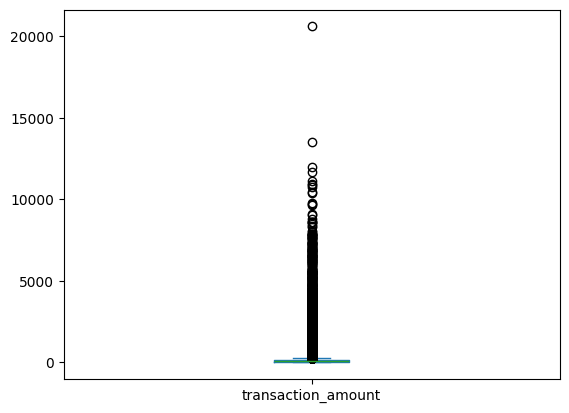

In [8]:
# Outlier
train["transaction_amount"].plot(kind="box")


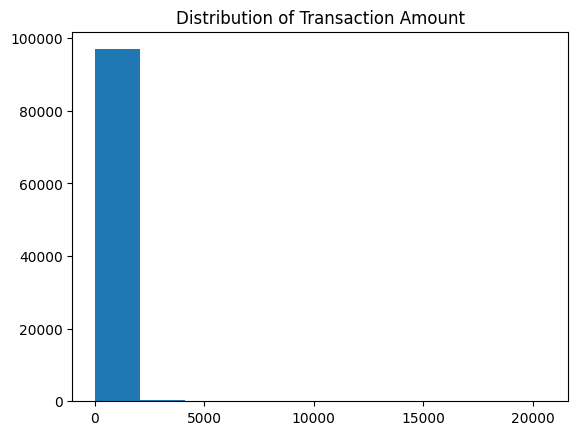

In [9]:
plt.hist(train["transaction_amount"])
plt.title("Distribution of Transaction Amount")
plt.show()


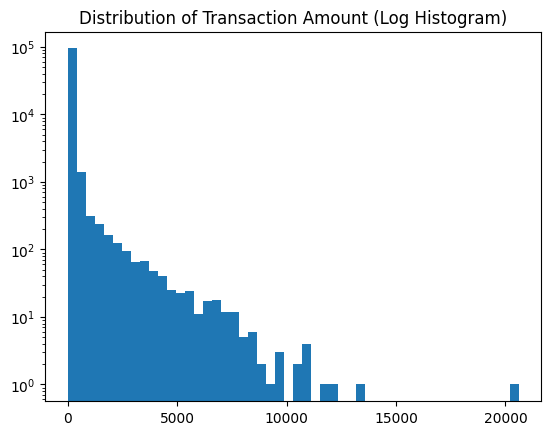

In [10]:
plt.hist(train["transaction_amount"], bins=50, log=True)
plt.title("Distribution of Transaction Amount (Log Histogram)")
plt.show()



In [36]:
new_train = train

In [37]:
new_train

,ID,transaction_id,user_id,age,gender,country,device_type,device_os,merchant_category,transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
0,0,T0065716,15307,35,M,UK,mobile,Android,clothing,17.70,...,0.79300,1056,0,1,1,0.10,0.04,9.66,0,1
1,1,T0027857,1226,54,F,IN,mobile,Android,restaurants,64.46,...,0.49948,1867,0,1,1,0.12,0.10,12.05,0,1
2,2,T0055953,16072,35,M,US,desktop,iOS,restaurants,5.20,...,0.28100,1726,1,2,2,0.12,0.05,181.28,0,0
3,3,T0083660,725,23,F,US,mobile,Android,electronics,180.70,...,0.06100,30,1,1,1,0.30,0.05,33.26,0,0
4,4,T0017674,7367,32,M,UK,mobile,Android,gas,35.45,...,0.59200,1386,0,3,1,0.05,0.04,174.83,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,T0046220,14692,72,M,IN,mobile,Android,electronics,7.67,...,0.88800,1593,0,0,0,0.30,0.10,321.83,0,0
99996,99996,T0098804,9462,37,F,UK,mobile,Android,restaurants,47.95,...,0.30600,673,0,6,2,0.12,0.04,48.53,0,1
99997,99997,T0048045,13581,19,F,US,mobile,Android,services,44.29,...,0.73500,1511,0,1,0,0.08,0.05,163.73,0,0
99998,99998,T0070053,6704,34,M,IN,mobile,Windows,electronics,64.46,...,0.49948,906,0,1,2,0.30,0.10,67.30,0,0


In [40]:
train.isna().sum()

ID                        0
transaction_id            0
user_id                   0
age                       0
gender                    0
country                   0
device_type               0
device_os                 0
merchant_category         0
transaction_amount        0
transaction_type          0
time_of_day               0
day_of_week               0
transaction_duration      0
num_prev_transactions     0
avg_transaction_amount    0
std_transaction_amount    0
transactions_last_24h     0
transactions_last_1h      0
failed_login_attempts     0
ip_risk_score             0
device_trust_score        0
account_age_days          0
has_chargeback_history    0
shared_ip_users           0
shared_device_users       0
merchant_risk             0
country_risk              0
distance_from_home        0
is_new_country            0
is_fraud                  0
dtype: int64

In [39]:
new_train.isna().sum()

ID                        0
transaction_id            0
user_id                   0
age                       0
gender                    0
country                   0
device_type               0
device_os                 0
merchant_category         0
transaction_amount        0
transaction_type          0
time_of_day               0
day_of_week               0
transaction_duration      0
num_prev_transactions     0
avg_transaction_amount    0
std_transaction_amount    0
transactions_last_24h     0
transactions_last_1h      0
failed_login_attempts     0
ip_risk_score             0
device_trust_score        0
account_age_days          0
has_chargeback_history    0
shared_ip_users           0
shared_device_users       0
merchant_risk             0
country_risk              0
distance_from_home        0
is_new_country            0
is_fraud                  0
dtype: int64